In [1]:
import os
os.listdir()


['.ipynb_checkpoints',
 'all_tickets_processed_improved_v3.csv',
 'support_ticket_classification.ipynb',
 'tfidf_vectorizer.pkl',
 'ticket_classifier_model.pkl']

In [3]:
import pandas as pd
df = pd.read_csv("all_tickets_processed_improved_v3.csv")
df.head()

,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


In [ ]:
import pandas as pd

df = pd.read_csv("customer_support_tickets.csv")

df.head()


In [ ]:
df.columns


In [ ]:
df.info()


In [ ]:
df.isnull().sum()


In [ ]:
# Keep only important columns
df = df[['Ticket Description', 'Ticket Type', 'Ticket Priority']]

df.head()


In [ ]:
df.isnull().sum()


In [25]:
import nltk
import re
import string
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kusum\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [24]:
def clean_text(text):
    text = text.lower()  # convert to lowercase
    text = re.sub(r'\d+', '', text)  # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    words = text.split()  # tokenize
    words = [word for word in words if word not in stop_words]  # remove stopwords
    return " ".join(words)


In [ ]:
df['cleaned_text'] = df['Ticket Description'].apply(clean_text)

df[['Ticket Description', 'cleaned_text']].head()


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)


In [ ]:
X = vectorizer.fit_transform(df['cleaned_text'])


In [ ]:
X.shape


In [ ]:
y_category = df['Ticket Type']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_category, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.linear_model import LogisticRegression

model_category = LogisticRegression(max_iter=1000)
model_category.fit(X_train, y_train)


In [ ]:
y_pred = model_category.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


In [ ]:
df['combined_text'] = df['Ticket Description'] + " " + df['Ticket Type']


In [ ]:
df['combined_text'] = df['Ticket Subject'] + " " + df['Ticket Description']


In [16]:
df = pd.read_csv("all_tickets_processed_improved_v3.csv")

In [18]:
df['combined_text'] = df['Document']

In [20]:
df = df[['combined_text', 'Topic_group']]

In [22]:
def clean_text(text):
    text = text.lower()  # convert to lowercase
    text = re.sub(r'\d+', '', text)  # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    words = text.split()  # tokenize
    words = [word for word in words if word not in stop_words]  # remove stopwords
    return " ".join(words)

In [26]:
df['cleaned_text'] = df['combined_text'].apply(clean_text)

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['cleaned_text'])


In [29]:
y = df['Topic_group']

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [31]:
from sklearn.linear_model import LogisticRegression

model_category = LogisticRegression(max_iter=1000)
model_category.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [32]:
y_pred = model_category.predict(X_test)


In [33]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.8510660535117057
                       precision    recall  f1-score   support

               Access       0.92      0.87      0.89      1455
Administrative rights       0.86      0.67      0.76       342
           HR Support       0.85      0.84      0.84      2107
             Hardware       0.80      0.89      0.84      2760
     Internal Project       0.93      0.80      0.86       451
        Miscellaneous       0.81      0.83      0.82      1400
             Purchase       0.97      0.87      0.92       497
              Storage       0.93      0.84      0.89       556

             accuracy                           0.85      9568
            macro avg       0.88      0.83      0.85      9568
         weighted avg       0.86      0.85      0.85      9568



In [34]:
import os
os.listdir()


['all_tickets_processed_improved_v3.csv',
 'LICENSE',
 'README.md',
 'support_ticket_classification.ipynb',
 'tfidf_vectorizer.pkl',
 'ticket_classifier_model.pkl']

In [35]:
import pandas as pd

df = pd.read_csv("all_tickets_processed_improved_v3.csv")
df.head()


,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


In [36]:
df.columns


Index(['Document', 'Topic_group'], dtype='str')

In [37]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 47837 entries, 0 to 47836
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Document     47837 non-null  str  
 1   Topic_group  47837 non-null  str  
dtypes: str(2)
memory usage: 14.5 MB


In [38]:
import nltk
import re
import string
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kusum\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [39]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)


In [40]:
df['cleaned_text'] = df['Document'].apply(clean_text)

df[['Document', 'cleaned_text']].head()


,Document,cleaned_text
0,connection with icon icon dear please setup ic...,connection icon icon dear please setup icon pe...
1,work experience user work experience user hi w...,work experience user work experience user hi w...
2,requesting for meeting requesting meeting hi p...,requesting meeting requesting meeting hi pleas...
3,reset passwords for external accounts re expir...,reset passwords external accounts expire days ...
4,mail verification warning hi has got attached ...,mail verification warning hi got attached plea...


In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [42]:
vectorizer = TfidfVectorizer(max_features=5000)


In [43]:
X = vectorizer.fit_transform(df['cleaned_text'])


In [44]:
X.shape


(47837, 5000)

In [45]:
y = df['Topic_group']


In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [47]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [48]:
y_pred = model.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


In [ ]:
import pickle

# Save model
pickle.dump(model, open("ticket_classifier_model.pkl", "wb"))

# Save vectorizer
pickle.dump(vectorizer, open("tfidf_vectorizer.pkl", "wb"))


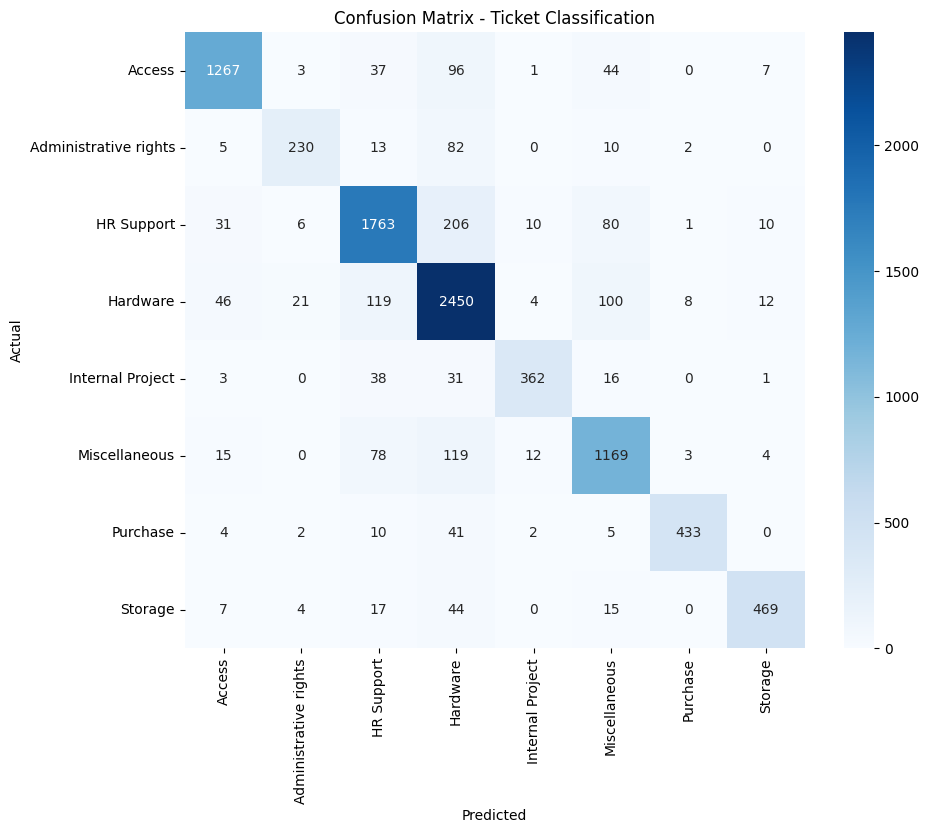

In [49]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Ticket Classification")
plt.show()

In [6]:
y = df['Topic_group']

In [5]:
import pandas as pd
import nltk
import re
import string
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [6]:
df = pd.read_csv("all_tickets_processed_improved_v3.csv")
df.head()

,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


In [7]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['cleaned_text'] = df['Document'].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SUKANYA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['cleaned_text'] = df['Document'].apply(clean_text)

df.head()

,Document,Topic_group,cleaned_text
0,connection with icon icon dear please setup ic...,Hardware,connection icon icon dear please setup icon pe...
1,work experience user work experience user hi w...,Access,work experience user work experience user hi w...
2,requesting for meeting requesting meeting hi p...,Hardware,requesting meeting requesting meeting hi pleas...
3,reset passwords for external accounts re expir...,Access,reset passwords external accounts expire days ...
4,mail verification warning hi has got attached ...,Miscellaneous,mail verification warning hi got attached plea...


In [9]:
pd.set_option('display.max_colwidth', None)
df.head()

,Document,Topic_group,cleaned_text
0,connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead,Hardware,connection icon icon dear please setup icon per icon engineers please let details needed thanks lead
1,work experience user work experience user hi work experience student coming next his name much appreciate him duration thank,Access,work experience user work experience user hi work experience student coming next name much appreciate duration thank
2,requesting for meeting requesting meeting hi please help follow equipments cable pc cord plug,Hardware,requesting meeting requesting meeting hi please help follow equipments cable pc cord plug
3,reset passwords for external accounts re expire days hi ask help update passwords colleagues thank pm expire days importance high hi received about expiration please kindly help prolongation best regards pm expire days importance high dear expire days order change please follow steps prerequisites disable device credentials close active connected by cable machine note also follow steps detailed press ctrl alt delete same pops change item enter format enter enter newly chosen then re enter again submit displaying has changed os machine browse enter format enter gear icon top tight browser window enter enter newly chosen then re enter again save connected note complete resources granted once connected by cable browse tick want change after logging enter format enter log enter enter newly chosen then re enter again change clients suppliers about expire please touch person then communicate back encounter issues hesitate by accessing yours,Access,reset passwords external accounts expire days hi ask help update passwords colleagues thank pm expire days importance high hi received expiration please kindly help prolongation best regards pm expire days importance high dear expire days order change please follow steps prerequisites disable device credentials close active connected cable machine note also follow steps detailed press ctrl alt delete pops change item enter format enter enter newly chosen enter submit displaying changed os machine browse enter format enter gear icon top tight browser window enter enter newly chosen enter save connected note complete resources granted connected cable browse tick want change logging enter format enter log enter enter newly chosen enter change clients suppliers expire please touch person communicate back encounter issues hesitate accessing
4,mail verification warning hi has got attached please addresses best regards monitoring analyst verification warning,Miscellaneous,mail verification warning hi got attached please addresses best regards monitoring analyst verification warning


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['cleaned_text'])

X.shape

(47837, 5000)

In [11]:
from sklearn.model_selection import train_test_split

y = df['Topic_group']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [13]:
y_pred = model.predict(X_test)

In [14]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8510660535117057
                       precision    recall  f1-score   support

               Access       0.92      0.87      0.89      1455
Administrative rights       0.86      0.67      0.76       342
           HR Support       0.85      0.84      0.84      2107
             Hardware       0.80      0.89      0.84      2760
     Internal Project       0.93      0.80      0.86       451
        Miscellaneous       0.81      0.83      0.82      1400
             Purchase       0.97      0.87      0.92       497
              Storage       0.93      0.84      0.89       556

             accuracy                           0.85      9568
            macro avg       0.88      0.83      0.85      9568
         weighted avg       0.86      0.85      0.85      9568



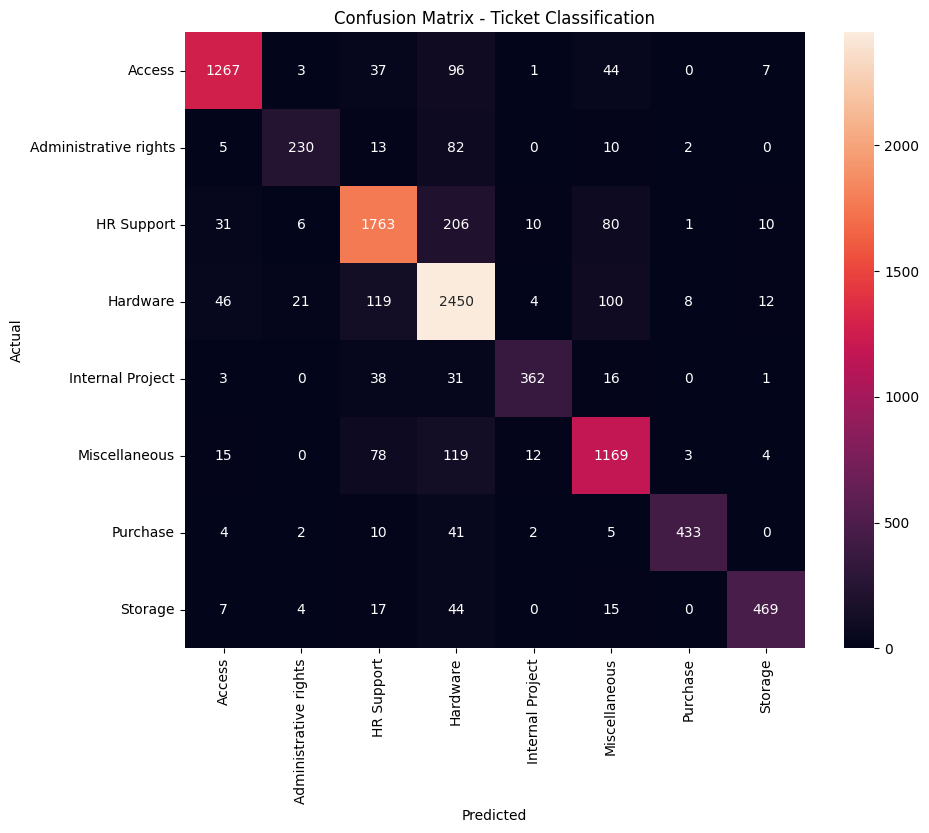

In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Ticket Classification")
plt.show()

In [51]:
def assign_priority(text):
    text = text.lower()
    
    high_keywords = ["urgent", "critical", "immediately", "down", "not working", "asap"]
    medium_keywords = ["request", "access", "issue", "error", "help"]
    
    for word in high_keywords:
        if word in text:
            return "High"
    
    for word in medium_keywords:
        if word in text:
            return "Medium"
    
    return "Low"

In [52]:
df["Predicted_Priority"] = df["Document"].apply(assign_priority)

df[["Document", "Predicted_Priority"]].head()

,Document,Predicted_Priority
0,connection with icon icon dear please setup ic...,Low
1,work experience user work experience user hi w...,Low
2,requesting for meeting requesting meeting hi p...,Medium
3,reset passwords for external accounts re expir...,Medium
4,mail verification warning hi has got attached ...,Low


In [20]:
df["Predicted_Priority"].value_counts()

Predicted_Priority
Medium    22883
Low       20102
High       4852
Name: count, dtype: int64

The dataset does not contain labeled priority levels.
Therefore, a rule-based priority assignment system was implemented.

Priority levels are assigned using urgency-related keywords such as:

"urgent"

"critical"

"down"

"immediately"

This simulates real-world urgency detection in support systems.